# Machine Learning — Lab 5: Linear Regression — House Prices

**Name:** Shiza Shaikh  
**Student ID:** 0525  
**Section:** C  
**GitHub:** shizashaikh55  
**Kaggle:** shiza_tech  
**Dataset:** House Prices — Advanced Regression Techniques  
**Dataset Source:** Kaggle




In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

Put these three files in the same folder as this notebook:

- `train.csv`
- `test.csv`
- `sample_submission.csv`

The code below searches the current directory and common Jupyter locations. If your files are somewhere else, change `DATA_DIR`.


In [17]:

DATA_DIR = Path(".")


candidates = [
    Path("."),
    Path("/content"),
    Path("/kaggle/input/house-prices-advanced-regression-techniques"),
    Path("/drive/MyDrive"),
]

data_dir = None
for folder in candidates:
    if (folder / "train.csv").exists() and (folder / "test.csv").exists():
        data_dir = folder
        break

if data_dir is None:
    raise FileNotFoundError(
        "train.csv and test.csv were not found. "
        "Place them beside this notebook or set DATA_DIR to their folder."
    )

train_path = data_dir / "train.csv"
test_path = data_dir / "test.csv"
sample_path = data_dir / "sample_submission.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample = pd.read_csv(sample_path) if sample_path.exists() else None

print("Data folder:", data_dir.resolve())
print("Train shape:", train.shape)
print("Test shape:", test.shape)
if sample is not None:
    print("Sample submission shape:", sample.shape)


Data folder: /drive/notebooks
Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)


## 3. Dataset Exploration

`SalePrice` is the dependent/target variable. This is a **regression** problem because the target is a continuous numeric house price, not a class label.


In [18]:
display(train.head())
print("\nTrain information:")
train.info()

print("\nSummary statistics:")
display(train.describe().T.head(15))

print("\nMissing values in selected variables:")
display(train.isna().sum().sort_values(ascending=False).head(15))


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Train information:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18 

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0



Missing values in selected variables:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
dtype: int64

### 3.1 Feature and Target Identification

For a manageable lab model, we use 12 features with a mixture of numerical and categorical variables. These are chosen because they represent quality, living area, basement/garage capacity, age/remodeling, rooms, and location/quality categories.

**Numerical:** `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`, `YearBuilt`, `YearRemodAdd`, `FullBath`, `TotRmsAbvGrd`

**Categorical:** `Neighborhood`, `KitchenQual`

**Target:** `SalePrice`


In [19]:
# 12 selected features required for the lab
features = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea",
    "TotalBsmtSF", "1stFlrSF", "YearBuilt", "YearRemodAdd",
    "FullBath", "TotRmsAbvGrd", "Neighborhood", "KitchenQual"
]

target = "SalePrice"

missing_features = [c for c in features + [target] if c not in train.columns]
if missing_features:
    raise KeyError(f"Missing columns: {missing_features}")

numeric_features = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea",
    "TotalBsmtSF", "1stFlrSF", "YearBuilt", "YearRemodAdd",
    "FullBath", "TotRmsAbvGrd"
]
categorical_features = ["Neighborhood", "KitchenQual"]

X = train[features].copy()
y = train[target].copy()

print("Selected features:", len(features))
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target:", target)


Selected features: 12
Numerical features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'YearBuilt', 'YearRemodAdd', 'FullBath', 'TotRmsAbvGrd']
Categorical features: ['Neighborhood', 'KitchenQual']
Target: SalePrice


## 4. Data Preparation

Numerical columns are median-imputed. Categorical columns are filled with the most frequent category and one-hot encoded. One-hot encoding is appropriate because categories such as neighborhood and kitchen quality do not have a safe numeric distance relationship for ordinary Linear Regression.


In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Check original missing values
print("Missing values before preprocessing:")
display(X.isna().sum())

# Fit only after the train/test split to avoid leakage


Missing values before preprocessing:


OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
YearBuilt       0
YearRemodAdd    0
FullBath        0
TotRmsAbvGrd    0
Neighborhood    0
KitchenQual     0
dtype: int64

## 5. Train/Test Split

We use an 80/20 split with a fixed random state so the result is reproducible.


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (1168, 12)
X_test : (292, 12)
y_train: (1168,)
y_test : (292,)


## 6. Linear Regression Model — Lab Model

The first model predicts the original `SalePrice` directly. This is the model used for the main lab metrics and coefficient interpretation.


In [22]:
lab_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lab_model.fit(X_train, y_train)
y_pred = lab_model.predict(X_test)

# Avoid impossible negative prices
y_pred = np.maximum(y_pred, 0)

print("Lab Linear Regression model trained successfully.")


Lab Linear Regression model trained successfully.


## 7. Predictions

The table below compares actual and predicted prices for 10 test houses.


In [23]:
prediction_table = pd.DataFrame({
    "Actual SalePrice": y_test.values[:10],
    "Predicted SalePrice": y_pred[:10]
})
display(prediction_table)


,Actual SalePrice,Predicted SalePrice
0,154500,143351.966698
1,325000,324761.745196
2,115000,103354.470369
3,159000,166526.577326
4,315500,317762.508240
5,75500,57143.494098
6,311500,231348.009007
7,146000,152380.726189
8,84500,56307.777861
9,135500,117711.913410


## 8. Coefficients and Intercept

The transformed feature names are extracted so that the coefficient table is readable. For one-hot encoded categories, a coefficient describes the change relative to the omitted/reference category, holding the other variables constant.


In [24]:
# Get transformed feature names
feature_names = lab_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = lab_model.named_steps["model"].coef_
intercept = lab_model.named_steps["model"].intercept_

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_table["Abs_Coefficient"] = coef_table["Coefficient"].abs()
coef_table = coef_table.sort_values("Abs_Coefficient", ascending=False)

print(f"Intercept: {intercept:,.2f}")
display(coef_table.drop(columns="Abs_Coefficient").head(30))


Intercept: -822,577.97


,Feature,Coefficient
25,cat__Neighborhood_NoRidge,54287.182797
32,cat__Neighborhood_StoneBr,41433.570253
34,cat__Neighborhood_Veenker,35168.003344
35,cat__KitchenQual_Ex,35011.502733
12,cat__Neighborhood_BrDale,-32398.500509
26,cat__Neighborhood_NridgHt,32045.730230
14,cat__Neighborhood_ClearCr,29904.146058
11,cat__Neighborhood_Blueste,-29178.289404
10,cat__Neighborhood_Blmngtn,-24324.372983
16,cat__Neighborhood_Crawfor,22767.188824


### Intercept interpretation

The intercept is the predicted price when all numeric variables are zero and all encoded categories are at their reference levels. That combination does not represent a realistic house, so the intercept is mainly a mathematical part of the regression equation rather than a meaningful real-world house price.


## 9. Residual Analysis

Residual = **actual − predicted**. Randomly scattered residuals around zero are generally more desirable than a clear curve or funnel pattern.


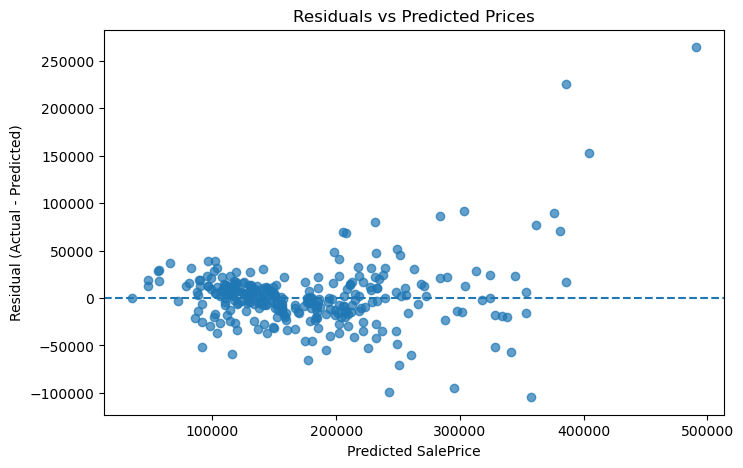

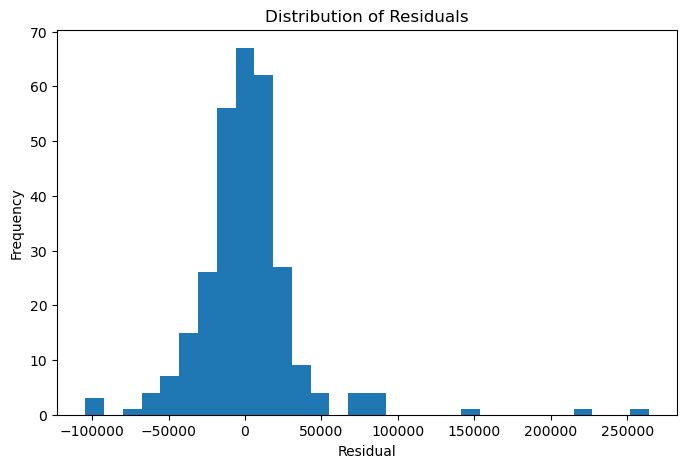

Residual mean: 1300.4082654342474


In [25]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Prices")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

print("Residual mean:", residuals.mean())


### Residual interpretation

If the residual points are roughly distributed around zero without a strong systematic curve, the model is capturing part of the relationship. Large spread or visible patterns indicate that a simple linear model cannot fully explain the house-price relationship.


## 10. Regression Metrics — Test Set

- **MAE:** average absolute prediction error in price units.
- **MSE:** average squared error; large errors receive more penalty.
- **RMSE:** square root of MSE, also in price units.
- **R²:** proportion of target variation explained by the model.


In [26]:
def regression_metrics(y_true, y_hat):
    mse = mean_squared_error(y_true, y_hat)
    return {
        "MAE": mean_absolute_error(y_true, y_hat),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_hat)
    }

test_metrics = regression_metrics(y_test, y_pred)
test_metrics_df = pd.DataFrame([test_metrics], index=["Test"])
display(test_metrics_df)


,MAE,MSE,RMSE,R2
Test,20998.548362,1.200949e+09,34654.708984,0.843429


### Metric interpretation

For a non-technical stakeholder, **MAE** is easy to explain because it tells the average absolute price error in the original price units. For this Kaggle competition, however, the official leaderboard uses a logarithmic RMSE metric, so the Kaggle model below uses `log1p(SalePrice)`.


## 11. Training vs Testing Performance

A large difference between training and test performance can indicate overfitting. Similar performance suggests better generalization.


In [27]:
train_pred = lab_model.predict(X_train)
train_pred = np.maximum(train_pred, 0)

train_metrics = regression_metrics(y_train, train_pred)

comparison = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
display(comparison)


,MAE,MSE,RMSE,R2
Train,20327.770153,1.068939e+09,32694.627475,0.820785
Test,20998.548362,1.200949e+09,34654.708984,0.843429


## 12. Kaggle-Oriented Linear Regression Model

Kaggle evaluates **RMSE between log(predicted price) and log(actual price)**. The competition is ongoing and uses a rolling leaderboard. citeturn0search1

To match that evaluation more closely while staying within the Linear Regression lab, we train the same selected features and preprocessing pipeline on `log1p(SalePrice)`. Predictions are converted back to price with `expm1`.

This is still Linear Regression; only the target scale is changed for the competition metric.


In [28]:
# Train a Kaggle-oriented Linear Regression model on log prices
kaggle_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

log_y_train = np.log1p(y_train)

kaggle_model.fit(X_train, log_y_train)

log_test_pred = kaggle_model.predict(X_test)
kaggle_test_pred = np.expm1(log_test_pred)
kaggle_test_pred = np.maximum(kaggle_test_pred, 0)

# Local approximation of Kaggle's RMSLE
local_kaggle_rmse = np.sqrt(
    mean_squared_error(np.log1p(y_test), np.log1p(kaggle_test_pred))
)

print(f"Local Kaggle-style RMSLE/RMSE(log): {local_kaggle_rmse:.5f}")


Local Kaggle-style RMSLE/RMSE(log): 0.15294


## 13. Final Kaggle Submission

The competition requires exactly two columns: `Id` and `SalePrice`. The code also checks the row count and prevents invalid negative prices.


In [29]:
# Refit the Kaggle-oriented model on ALL labeled training data
final_kaggle_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

final_kaggle_model.fit(X, np.log1p(y))

X_kaggle_test = test[features].copy()
final_log_pred = final_kaggle_model.predict(X_kaggle_test)
final_pred = np.expm1(final_log_pred)
final_pred = np.maximum(final_pred, 0)

submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": final_pred
})

# Exact validation before saving
assert list(submission.columns) == ["Id", "SalePrice"]
assert len(submission) == len(test)
assert submission["SalePrice"].notna().all()
assert (submission["SalePrice"] >= 0).all()

submission_path = Path("submission.csv")
submission.to_csv(submission_path, index=False)

print("Submission created:", submission_path.resolve())
print("Rows:", len(submission))
display(submission.head(10))


Submission created: /drive/notebooks/submission.csv
Rows: 1459


,Id,SalePrice
0,1461,121622.898503
1,1462,148917.411523
2,1463,163492.933092
3,1464,183283.672348
4,1465,229184.282559
5,1466,173580.108140
6,1467,167436.742642
7,1468,169346.334330
8,1469,189070.652876
9,1470,118440.682852


In [ ]:
## Kaggle Leaderboard Result

My Linear Regression model was submitted successfully to the Kaggle House Prices competition.

- **Kaggle Public Score:*051751* 
- **Kaggle Rank:*2504* 

The submission was successfully accepted by Kaggle. The leaderboard score shows how the model performed on Kaggle's unseen test data compared with other submissions.